In [16]:
# --------------------------------------------------------
# Import packages
# --------------------------------------------------------
import optax
from jax import jit, value_and_grad, hessian
import jax.numpy as jnp
import matplotlib.pyplot as plt

from diffPLOG2TROE.kinetic_constants import FallOff, Plog

In [13]:
plog_dictionary = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03]
        ]
    }
}
starting_plog = Plog(plog_dictionary)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 100)

k_plog = starting_plog.kinetic_constant(T_range, P_range)

In [47]:
@jit
def loss_function(params):
    falloff = FallOff(
        name="",
        hpl_params=jnp.array([1.500e14, 0.167, 0.000e00]),
        lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2] * 1.987]),
        falloff_params=jnp.array([params[3], jnp.exp(params[4]), jnp.exp(params[5]), jnp.exp(params[6])]),
        falloff_type="troe",
    )
    predictions = falloff.kinetic_constant(T_range, P_range)[0]
    return jnp.mean((jnp.log(predictions) - jnp.log(k_plog)) ** 2)


def optimize(params, constraint_type="", num_iterations=1000, learning_rate=0.01):
    # optimizer = optax.adam(learning_rate)
    optimizer = optax.lbfgs(learning_rate)
    opt_state = optimizer.init(params)

    @jit
    def update_step(params, opt_state):
        # Compute gradients
        loss, grads = value_and_grad(loss_function)(params)
        
        # Apply optimizer update
        # updates, opt_state = optimizer.update(grads, opt_state)
        updates, new_opt_state = optimizer.update(grads, opt_state, params=params, value=loss, grad=grads, value_fn=loss_function,)
        params = optax.apply_updates(params, updates)
        
        # Apply projection to enforce constraints if needed
        # params = project(params)

        return params, opt_state, loss

    losses = []
    for i in range(num_iterations):
        params, opt_state, loss = update_step(params, opt_state)
        losses.append(loss)
        if i % 800 == 0:
            print(f"Iteration {i}, Loss: {loss:.6f}")

    return params, losses


In [48]:
initial_guess = jnp.array([
    jnp.log(9.954e29),
    -3.959,
    2.807e03 / 1.987,
    0.500,
    jnp.log(9.800e02),
    jnp.log(2.800e02),
    jnp.log(2.100e03)
], dtype=jnp.float64,)

results = {}
params, losses = optimize(initial_guess, num_iterations=40000, learning_rate=0.01)
results["None"] = (params, losses)

# Check loss and constraint satisfaction
final_loss = loss_function(params)
print(f"Final loss: {final_loss:.6f}")

Iteration 0, Loss: 0.022216
Iteration 800, Loss: 0.005916
Iteration 1600, Loss: 0.004399
Iteration 2400, Loss: 0.003132
Iteration 3200, Loss: 0.002342
Iteration 4000, Loss: 0.001826
Iteration 4800, Loss: 0.001519
Iteration 5600, Loss: 0.001350
Iteration 6400, Loss: 0.001257
Iteration 7200, Loss: 0.001206
Iteration 8000, Loss: 0.001174
Iteration 8800, Loss: 0.001157
Iteration 9600, Loss: 0.001147
Iteration 10400, Loss: 0.001140
Iteration 11200, Loss: 0.001137
Iteration 12000, Loss: 0.001134
Iteration 12800, Loss: 0.001133
Iteration 13600, Loss: 0.001132
Iteration 14400, Loss: 0.001131
Iteration 15200, Loss: 0.001130
Iteration 16000, Loss: 0.001130
Iteration 16800, Loss: 0.001130
Iteration 17600, Loss: 0.001129
Iteration 18400, Loss: 0.001129
Iteration 19200, Loss: 0.001129
Iteration 20000, Loss: 0.001128
Iteration 20800, Loss: 0.001128
Iteration 21600, Loss: 0.001128
Iteration 22400, Loss: 0.001128
Iteration 23200, Loss: 0.001128
Iteration 24000, Loss: 0.001127
Iteration 24800, Loss: 0.

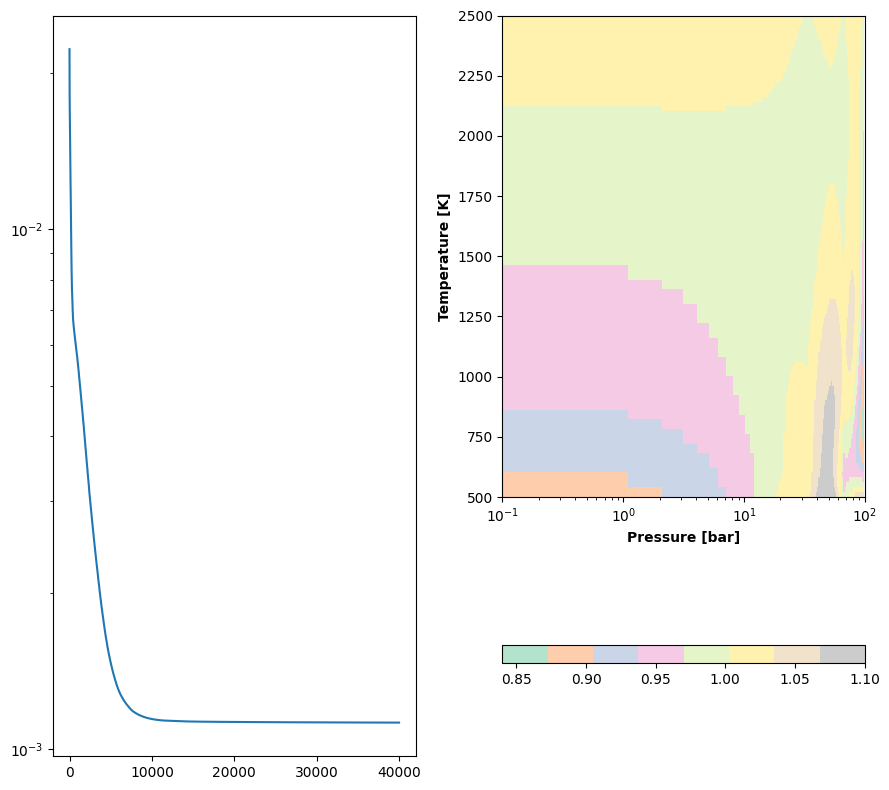

Final rate constant:
NH2+H=NH3		1.50000e+14 0.16700 0.00000e+00
 LOW / 		8.68691e+29 -3.89872 2.80701e+03 /
 TROE / 5.45966e-01 2.32502e+03 1.29277e+02 7.22467e+03 /

Minimum error: 0.8399462395452847
Maximum error: 1.1002974518023292
Average error: 0.99941910284878


In [49]:

fig, ax = plt.subplots(1, 2, figsize=(9, 8))
ax = ax.flatten()

# Fig 1
ax[0].plot(losses)
ax[0].set_yscale("log")

# Fig 2
k_plog = starting_plog.kinetic_constant(T_range, P_range)
falloff = FallOff(
    name="NH2+H=NH3",
    hpl_params=jnp.array([1.500e14, 0.167, 0.000e00]),
    lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2] * 1.987]),
    falloff_params=jnp.array([params[3], jnp.exp(params[4]), jnp.exp(params[5]), jnp.exp(params[6])]),
    falloff_type="troe",
)
k_troe = falloff.kinetic_constant(T_range, P_range)[0]

ratio = k_troe.T / k_plog.T

im = ax[1].imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    # cmap="jet"
    cmap="Pastel2"
)

ax[1].set_xscale("log")
ax[1].set_xlabel("Pressure [bar]", fontweight="bold")
ax[1].set_ylabel("Temperature [K]", fontweight="bold")
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

fig.tight_layout()
plt.show()

print(f"Final rate constant:\n{falloff}")
print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {jnp.mean(ratio)}")

In [50]:
import numpy as np
import seaborn as sns
import jax

def estimate_covariance(hessian, regularization=1e-6):
    try:
        # Ensure symmetry
        hessian_np = (hessian + hessian.T) / 2

        # Add small regularization to diagonal for numerical stability
        n = hessian_np.shape[0]
        hessian_reg = hessian_np + jnp.eye(n) * regularization

        # Invert the Hessian to get the covariance matrix
        return jnp.linalg.inv(hessian_reg)
    except:
        # If still singular after regularization, use pseudoinverse
        print("Warning: Hessian is singular even with regularization, using pseudoinverse")
        hessian_np = (hessian + hessian.T) / 2
        return jnp.linalg.pinv(hessian_np)

def analyze_parameter_covariance(func, optimal_params, param_names, regularization=1e-6):
    # Calculate Hessian at the optimum using JAX
    computed_hessian = hessian(loss_function)(optimal_params)

    # Print the condition number of the Hessian
    try:
        cond_num = jnp.linalg.cond(computed_hessian)
        print(f"Hessian condition number: {cond_num:.2e}")
        if cond_num > 1e10:
            print("Warning: Hessian is poorly conditioned, results may be unstable")
    except:
        print("Could not compute condition number of Hessian")

    # Estimate covariance matrix with regularization
    cov_matrix = estimate_covariance(computed_hessian, regularization)

    # Calculate the correlation matrix
    std_devs = jnp.sqrt(jnp.abs(jnp.diag(cov_matrix)))  # Use abs to avoid negative values from numerical issues
    corr_matrix = jnp.zeros_like(cov_matrix)

    for i in range(len(optimal_params)):
        for j in range(len(optimal_params)):
            # Handle cases where standard deviation is zero or NaN
            if jnp.isnan(std_devs[i]) or jnp.isnan(std_devs[j]) or std_devs[i] == 0 or std_devs[j] == 0:
                corr_matrix = corr_matrix.at[i, j].set(jnp.nan)
            else:
                corr_val = cov_matrix[i, j] / (std_devs[i] * std_devs[j])
                # Cap correlation at [-1, 1] to handle numerical issues
                corr_val = jnp.clip(corr_val, -1.0, 1.0)
                corr_matrix = corr_matrix.at[i, j].set(corr_val)

    # Calculate confidence intervals (95%)
    confidence_intervals = []
    for i, param in enumerate(optimal_params):
        if jnp.isnan(std_devs[i]):
            ci = (jnp.nan, jnp.nan)
        else:
            ci = (param - 1.96 * std_devs[i], param + 1.96 * std_devs[i])
        confidence_intervals.append(ci)

    # Return all information
    info = {
        "hessian": hessian,
        "covariance": cov_matrix,
        "correlation": corr_matrix,
        "std_devs": std_devs,
        "confidence_intervals": confidence_intervals,
    }

    # Identify parameters with valid and invalid uncertainties
    valid_indices = []
    invalid_indices = []
    for i, std in enumerate(std_devs):
        if jnp.isnan(std) or std == 0:
            invalid_indices.append(i)
        else:
            valid_indices.append(i)

    print(f"\nParameters with valid uncertainties: {[param_names[i] for i in valid_indices]}")
    print(f"Parameters with invalid uncertainties: {[param_names[i] for i in invalid_indices]}")

    # Plot the correlation matrix (masking NaN values)
    plt.figure(figsize=(10, 8))
    mask = jnp.isnan(corr_matrix)

    # Convert to numpy for seaborn compatibility
    corr_matrix_np = np.array(corr_matrix)
    mask_np = np.array(mask)

    sns.heatmap(
        corr_matrix_np,
        annot=True,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        xticklabels=param_names,
        yticklabels=param_names,
        mask=mask_np,
    )
    plt.title("Parameter Correlation Matrix")
    plt.tight_layout()
    plt.savefig("parameter_correlation.png", dpi=300)

    # Print parameter uncertainties
    print("\n=== Parameter Uncertainties (Standard Errors) ===")
    for i, name in enumerate(param_names):
        uncertainty = "NaN" if jnp.isnan(std_devs[i]) else f"{std_devs[i]:.6f}"
        print(f"{name}: {optimal_params[i]:.6f} ± {uncertainty}")

    # Print parameter confidence intervals
    print("\n=== Parameter 95% Confidence Intervals ===")
    for i, name in enumerate(param_names):
        ci = confidence_intervals[i]
        if jnp.isnan(ci[0]) or jnp.isnan(ci[1]):
            print(f"{name}: (NaN, NaN)")
        else:
            print(f"{name}: ({ci[0]:.6f}, {ci[1]:.6f})")

    return info

def plot_parameter_pairs(optimal_params, cov_matrix, param_names):
    """
    Plot pairwise distributions assuming a multivariate normal, handling NaN values.

    Args:
        optimal_params: Optimal parameters found by optimization
        cov_matrix: Covariance matrix
        param_names: List of parameter names
    """
    # Identify parameters with valid uncertainties
    valid_indices = []
    for i in range(len(optimal_params)):
        if not jnp.isnan(jnp.diag(cov_matrix)[i]) and jnp.diag(cov_matrix)[i] > 0:
            valid_indices.append(i)

    # Skip if no valid parameters
    if len(valid_indices) == 0:
        print("No parameters have valid uncertainties, skipping pair plots")
        return

    # Filter to include only valid parameters
    filtered_params = jnp.array([optimal_params[i] for i in valid_indices])
    filtered_names = [param_names[i] for i in valid_indices]

    # Extract valid submatrix of covariance
    n_valid = len(valid_indices)
    filtered_cov = jnp.zeros((n_valid, n_valid))
    for i in range(n_valid):
        for j in range(n_valid):
            filtered_cov = filtered_cov.at[i, j].set(cov_matrix[valid_indices[i], valid_indices[j]])

    # Create plots only for valid parameters
    fig, axes = plt.subplots(n_valid, n_valid, figsize=(15, 15))

    # If only one parameter is valid, reshape axes for indexing
    if n_valid == 1:
        axes = jnp.array([[axes]])

    # Generate multivariate normal samples around the optimum
    try:
        # Try to generate samples - might fail if covariance is still ill-conditioned
        key = jax.random.PRNGKey(0)
        samples = jax.random.multivariate_normal(key, mean=filtered_params, cov=filtered_cov, shape=(1000,))

        # Plot each parameter pair
        for i in range(n_valid):
            for j in range(n_valid):
                ax = axes[i, j]

                if i == j:
                    # Diagonal: plot histogram
                    ax.hist(samples[:, i], bins=20, alpha=0.7)
                    ax.axvline(filtered_params[i], color="r", linestyle="--")

                    # Add parameter name
                    if i == 0:
                        ax.set_title(filtered_names[i])
                else:
                    # Off-diagonal: plot scatter
                    ax.scatter(samples[:, j], samples[:, i], alpha=0.1, s=1)
                    ax.scatter([filtered_params[j]], [filtered_params[i]], color="r", s=20)

                    # Add parameter names
                    if i == n_valid - 1:
                        ax.set_xlabel(filtered_names[j])
                    if j == 0:
                        ax.set_ylabel(filtered_names[i])

        plt.tight_layout()
        plt.savefig("parameter_pairs.png", dpi=300)

    except Exception as e:
        print(f"Error generating multivariate samples: {e}")
        print("Skipping pair plots due to ill-conditioned covariance matrix")


def find_identifiability_issues(hessian, param_names, threshold=1e-6):
    # Compute eigendecomposition of the Hessian
    try:
        eigvals, eigvecs = jnp.linalg.eigh(hessian)

        # Sort eigenvalues and eigenvectors
        idx = jnp.argsort(jnp.abs(eigvals))
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        # Identify small eigenvalues (indicating poor identifiability)
        small_indices = jnp.where(jnp.abs(eigvals) < threshold)[0]

        if len(small_indices) > 0:
            print("\n=== Parameter Identifiability Analysis ===")
            print(f"Found {len(small_indices)} small eigenvalues (< {threshold})")

            # For each small eigenvalue, show the parameters contributing the most
            for i, idx in enumerate(small_indices):
                eigen_mode = eigvecs[:, idx]

                # Get absolute contributions
                contributions = jnp.abs(eigen_mode)

                # Sort parameters by contribution
                sorted_idx = jnp.argsort(-contributions)

                print(f"\nEigenvalue {i + 1}: {eigvals[idx]:.2e}")
                print("Major contributing parameters:")

                # Show top contributors
                for j in range(min(3, len(param_names))):
                    param_idx = sorted_idx[j]
                    print(f"  {param_names[param_idx]}: {contributions[param_idx]:.4f}")

            # Suggestions for improving identifiability
            print("\nSuggestions for improving parameter identifiability:")
            print("1. Fix some parameters to literature values")
            print("2. Reparameterize the model to reduce correlations")
            print("3. Collect more data or different experimental conditions")
            print("4. Use Bayesian methods with informative priors")

        return {"eigenvalues": eigvals, "eigenvectors": eigvecs, "small_eigenvalue_indices": small_indices}
    except:
        print("Could not perform eigendecomposition of the Hessian")
        return None


=== Analyzing Parameter Covariance ===
Hessian condition number: 6.90e+10

Parameters with valid uncertainties: ['ln(A) [cm³/mol·s]', 'n', 'E/R [K]', 'α', 'T*** [K]', 'T* [K]', 'T** [K]']
Parameters with invalid uncertainties: []

=== Parameter Uncertainties (Standard Errors) ===
ln(A) [cm³/mol·s]: 68.936785 ± 39.568357
n: -3.898724 ± 5.426869
E/R [K]: 1412.685204 ± 999.399021
α: 0.545966 ± 4.698986
T*** [K]: 7.751484 ± 20.493164
T* [K]: 4.861959 ± 69.500895
T** [K]: 8.885257 ± 15.032625

=== Parameter 95% Confidence Intervals ===
ln(A) [cm³/mol·s]: (-8.617194, 146.490764)
n: (-14.535388, 6.737940)
E/R [K]: (-546.136877, 3371.507285)
α: (-8.664046, 9.755978)
T*** [K]: (-32.415117, 47.918086)
T* [K]: (-131.359795, 141.083713)
T** [K]: (-20.578687, 38.349202)
Could not perform eigendecomposition of the Hessian

=== Plotting Parameter Pairs ===

Covariance analysis complete!


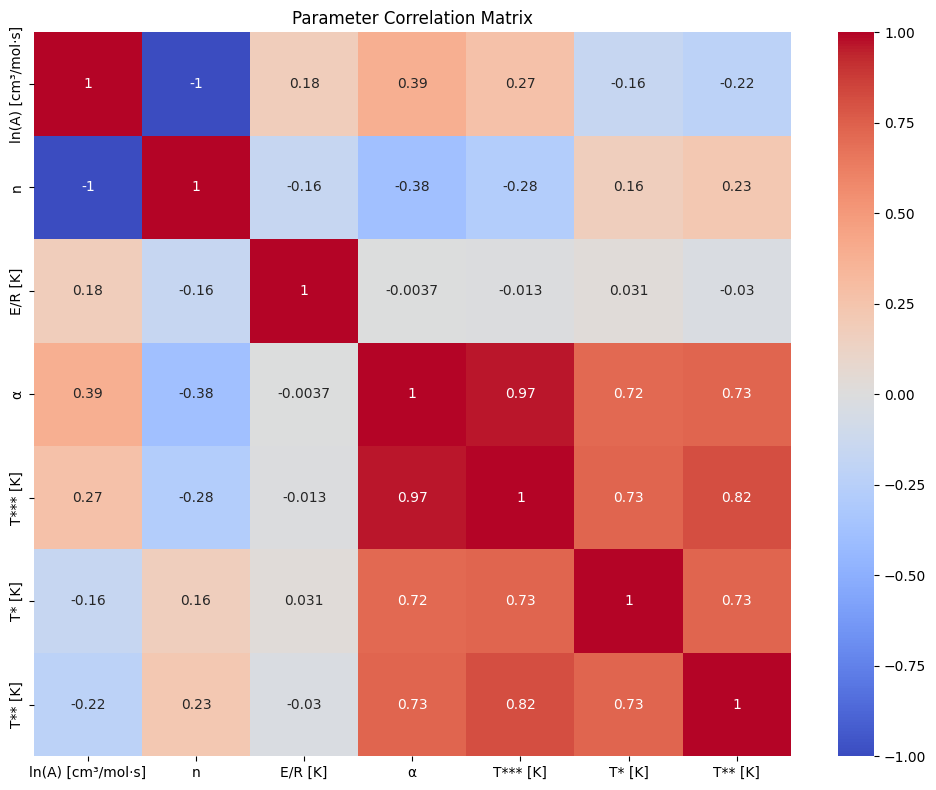

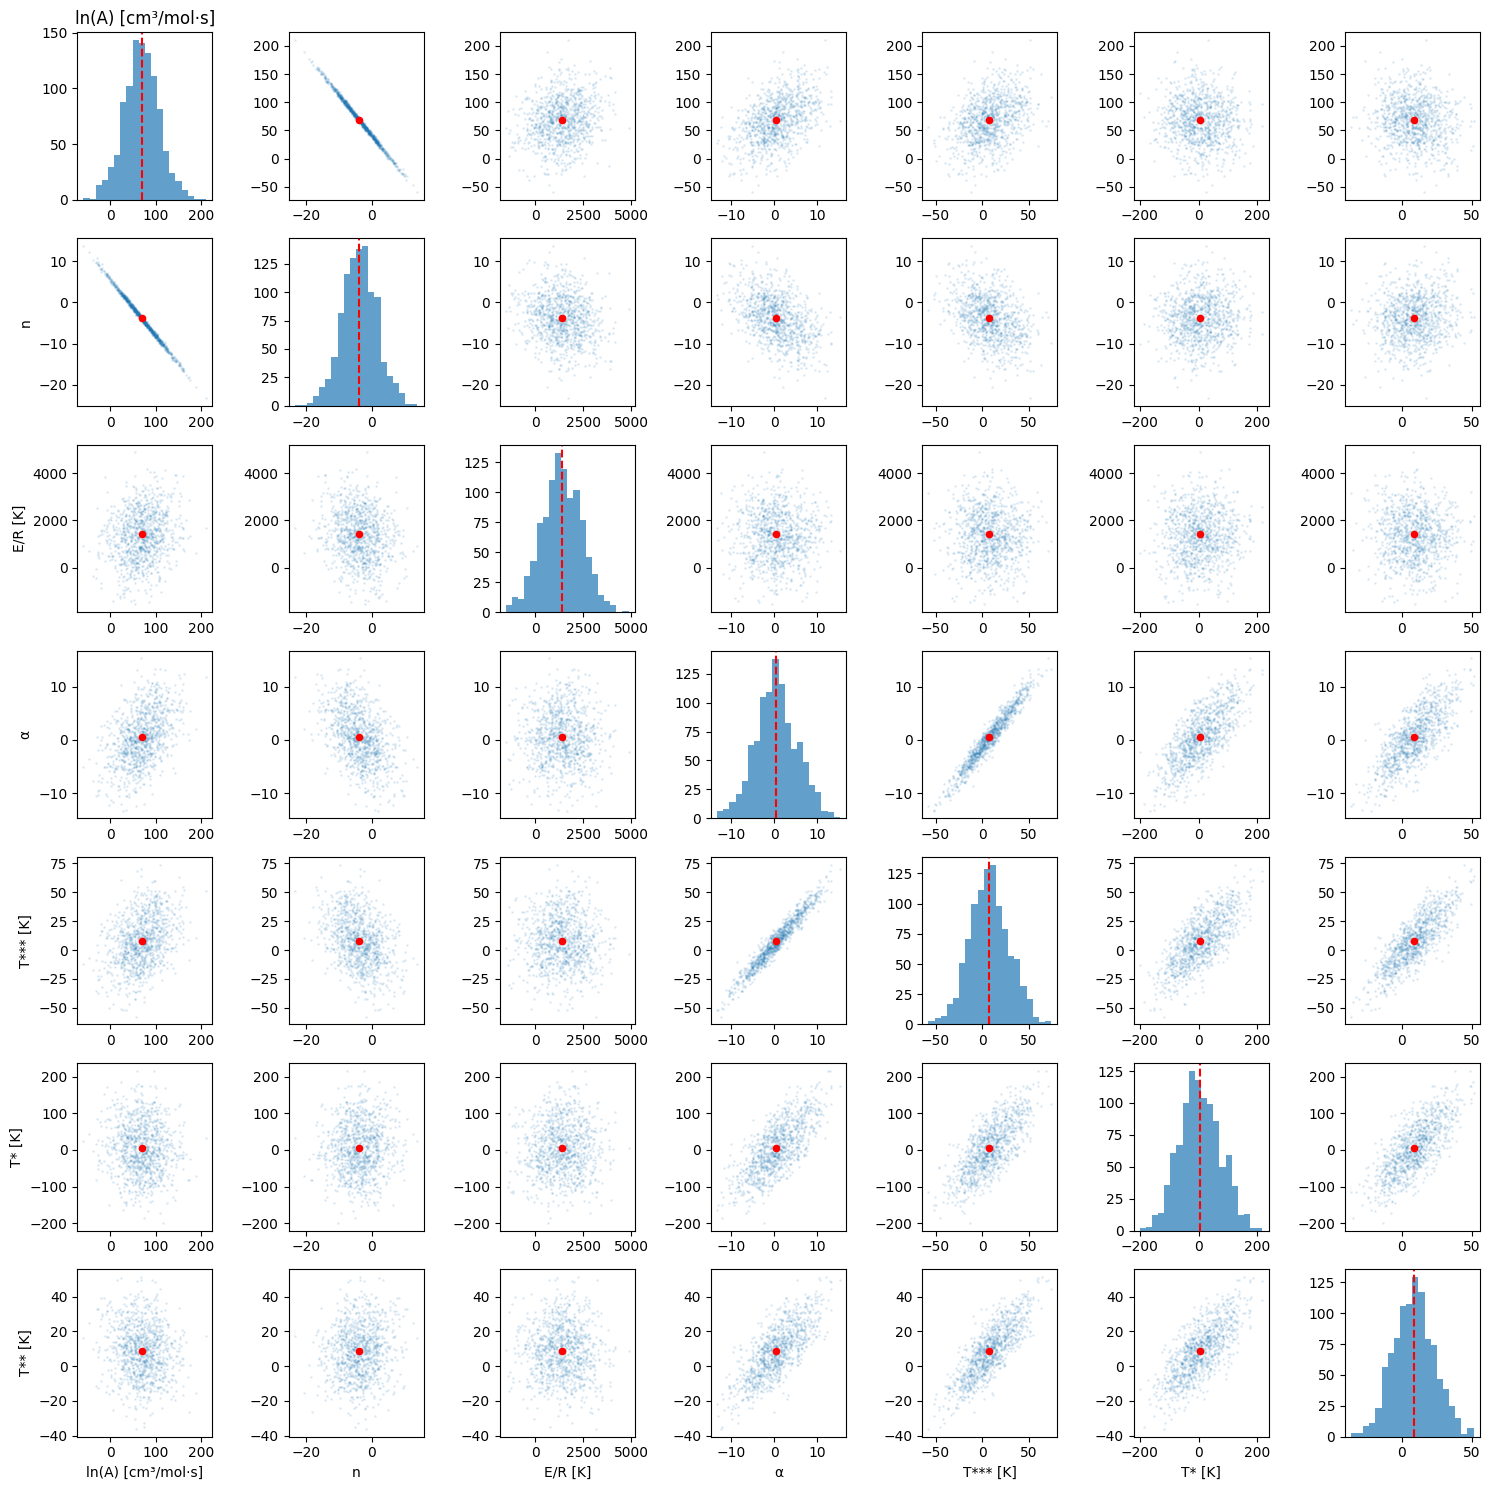

In [51]:
param_names = ["ln(A) [cm³/mol·s]", "n", "E/R [K]", "α", "T*** [K]", "T* [K]", "T** [K]"]

# Analyze covariance
print("\n=== Analyzing Parameter Covariance ===")
info = analyze_parameter_covariance(loss_function, params, param_names)

# Analyze parameter identifiability
find_identifiability_issues(info["hessian"], param_names)

# Plot parameter pairs for valid parameters
print("\n=== Plotting Parameter Pairs ===")
plot_parameter_pairs(params, info["covariance"], param_names)

print("\nCovariance analysis complete!")